# TASK 3 — Improved Model, Ablation, Explainability-ready, Fair Comparison

In [1]:
# SETUP, CONFIG, PATIENT-AWARE SPLIT PRIMITIVES

import os, random, hashlib, json, math, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except Exception:
    HAS_SMOTE = False

from scipy.stats import wilcoxon, binomtest
try:
    from statsmodels.stats.contingency_tables import mcnemar as sm_mcnemar
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DATASET_ROOT = "/kaggle/input/datasets/orvile/octdl-optical-coherence-tomography-dataset"
DATASET_DIR = f"{DATASET_ROOT}/OCTDL/OCTDL"
LABELS_PATH = f"{DATASET_ROOT}/OCTDL/OCTDL_labels.csv"

classes = ['AMD', 'DME', 'ERM', 'NO', 'RAO', 'RVO', 'VID']
class_to_idx = {c: i for i, c in enumerate(classes)}
NUM_CLASSES = len(classes)

IMAGE_SIZE = 128
GRID_SIZE = 8
PATCH_SIZE = IMAGE_SIZE // GRID_SIZE
BATCH_SIZE = 16
NUM_WORKERS = 2
LR = 3e-4
WEIGHT_DECAY = 2e-4
EPOCHS = 25
PATIENCE = 5
LABEL_SMOOTHING = 0.05
CV_EPOCHS = EPOCHS      
                                                 
CV_PATIENCE = 4

ARTIFACT_DIR = Path("/kaggle/working/task3_artifacts_fixed")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = Path("/kaggle/working/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.05


Device: cuda
GPU: Tesla T4


In [2]:
# 1. SCAN + CLEAN IMAGES, JOIN WITH patient_id FROM OCTDL_labels.csv

labels_df = pd.read_csv(LABELS_PATH)
print("Labels shape:", labels_df.shape)
display(labels_df.head())

assert "file_name" in labels_df.columns, "OCTDL_labels.csv must contain file_name"
assert "patient_id" in labels_df.columns, "OCTDL_labels.csv must contain patient_id"

file_to_patient = dict(zip(labels_df["file_name"], labels_df["patient_id"]))


def scan_clean_dataset(root):
    seen = set()
    paths, labels, patient_ids = [], [], []
    corrupt, duplicate, unmatched = 0, 0, 0
    for r, _, files in os.walk(root):
        cls = os.path.basename(r)
        if cls not in class_to_idx:
            continue
        for fn in files:
            if not fn.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
                continue
            p = os.path.join(r, fn)
            try:
                with Image.open(p) as im:
                    im.verify()
            except Exception:
                corrupt += 1
                continue
            h = hashlib.sha256()
            with open(p, "rb") as f:
                for chunk in iter(lambda: f.read(1024 * 1024), b""):
                    h.update(chunk)
            key = h.hexdigest()
            if key in seen:
                duplicate += 1
                continue
            seen.add(key)

            pid = file_to_patient.get(fn, file_to_patient.get(Path(fn).stem))
            if pid is None:
                unmatched += 1
                continue

            paths.append(p)
            labels.append(class_to_idx[cls])
            patient_ids.append(pid)
    return paths, labels, patient_ids, corrupt, duplicate, unmatched


clean_filepaths, clean_labels, clean_patients, corrupt_count, duplicate_count, unmatched_count = \
    scan_clean_dataset(DATASET_DIR)

print("Clean images:", len(clean_filepaths),
      "| corrupt:", corrupt_count,
      "| duplicates:", duplicate_count,
      "| unmatched to a patient_id:", unmatched_count)
print("Unique patients:", len(set(clean_patients)))

assert unmatched_count == 0, (
    "Some images could not be matched to a patient_id via file_name. "
    "Inspect labels_df['file_name'] formatting vs the on-disk filenames before continuing."
)


Labels shape: (2064, 10)


,file_name,disease,subcategory,condition,patient_id,eye,sex,year,image_width,image_hight
0,amd_1047099_1,AMD,intermediate,MNV_suspected,1047099,0,0,0,1101,410
1,amd_1047099_2,AMD,intermediate,MNV_suspected,1047099,0,0,0,731,265
2,amd_1047099_3,AMD,intermediate,MNV_suspected,1047099,0,0,0,1100,410
3,amd_1047099_4,AMD,intermediate,MNV_suspected,1047099,0,0,0,882,321
4,amd_1084498_1,AMD,late,MNV,1084498,0,0,0,882,321


Clean images: 2063 | corrupt: 0 | duplicates: 1 | unmatched to a patient_id: 0
Unique patients: 820


In [3]:
# 2. PATIENT-GROUPED 70/15/15 SPLIT (leakage-free)

clean_filepaths = np.array(clean_filepaths)
clean_labels = np.array(clean_labels)
clean_patients = np.array(clean_patients)

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss1.split(clean_filepaths, clean_labels, groups=clean_patients))

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel_idx, test_rel_idx = next(gss2.split(
    clean_filepaths[temp_idx], clean_labels[temp_idx], groups=clean_patients[temp_idx]
))
val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

train_paths = clean_filepaths[train_idx].tolist()
val_paths = clean_filepaths[val_idx].tolist()
test_paths = clean_filepaths[test_idx].tolist()
train_labels = clean_labels[train_idx].tolist()
val_labels = clean_labels[val_idx].tolist()
test_labels = clean_labels[test_idx].tolist()
train_patients = clean_patients[train_idx]
val_patients = clean_patients[val_idx]
test_patients = clean_patients[test_idx]

print("Split (images):", len(train_paths), len(val_paths), len(test_paths))
print("Split (patients):", len(set(train_patients)), len(set(val_patients)), len(set(test_patients)))

# Leakage check: verify no patient appears in more than one split.
overlap_tv = set(train_patients) & set(val_patients)
overlap_tt = set(train_patients) & set(test_patients)
overlap_vt = set(val_patients) & set(test_patients)
print("Patient overlap train/val:", len(overlap_tv))
print("Patient overlap train/test:", len(overlap_tt))
print("Patient overlap val/test:", len(overlap_vt))
assert not (overlap_tv or overlap_tt or overlap_vt), "Patient leakage detected across splits!"

# Persist the exact split so the companion XAI (SHAP/LIME) notebook can reload
# identical train/val/test sets without recomputing anything.
pd.DataFrame({"path": train_paths, "label": train_labels, "patient_id": train_patients}) \
    .to_csv(ARTIFACT_DIR / "train_split.csv", index=False)
pd.DataFrame({"path": val_paths, "label": val_labels, "patient_id": val_patients}) \
    .to_csv(ARTIFACT_DIR / "val_split.csv", index=False)
pd.DataFrame({"path": test_paths, "label": test_labels, "patient_id": test_patients}) \
    .to_csv(ARTIFACT_DIR / "test_split.csv", index=False)
print("Saved train/val/test split manifests to", ARTIFACT_DIR)


Split (images): 1455 294 314
Split (patients): 574 123 123
Patient overlap train/val: 0
Patient overlap train/test: 0
Patient overlap val/test: 0
Saved train/val/test split manifests to /kaggle/working/task3_artifacts_fixed


In [4]:
# 3. TRANSFORMS, DATASET, LOADERS

train_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=5, translate=(0.03, 0.03), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


class OCTDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths, self.labels = paths, labels
        self.transform = transform or eval_tfms

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        with Image.open(self.paths[i]) as im:
            im = im.convert("L")
            x = self.transform(im)
        return x, torch.tensor(self.labels[i], dtype=torch.long)


def make_loader(paths, labels, shuffle=False, augment=False):
    ds = OCTDataset(paths, labels, train_tfms if augment else eval_tfms)
    return DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=shuffle,
        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
    )


train_loader = make_loader(train_paths, train_labels, True, True)
val_loader = make_loader(val_paths, val_labels, False, False)
test_loader = make_loader(test_paths, test_labels, False, False)


def class_weights(labels):
    counts = np.bincount(labels, minlength=NUM_CLASSES).astype(np.float32)
    w = 1.0 / np.sqrt(np.maximum(counts, 1.0))
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)


WEIGHTS = class_weights(train_labels)
print("Class weights:", dict(zip(classes, WEIGHTS.detach().cpu().numpy().round(3))))


Class weights: {'AMD': np.float32(0.292), 'DME': np.float32(0.824), 'ERM': np.float32(0.874), 'NO': np.float32(0.551), 'RAO': np.float32(2.222), 'RVO': np.float32(1.007), 'VID': np.float32(1.229)}


In [5]:
# 4. MODEL ARCHITECTURE 

def grid_adjacency(n=GRID_SIZE, weighted=False):
    A = np.zeros((n * n, n * n), dtype=np.float32)
    for r in range(n):
        for c in range(n):
            i = r * n + c
            for dr in (-1, 0, 1):
                for dc in (-1, 0, 1):
                    if dr == 0 and dc == 0:
                        continue
                    rr, cc = r + dr, c + dc
                    if 0 <= rr < n and 0 <= cc < n:
                        j = rr * n + cc
                        d = (dr * dr + dc * dc) ** 0.5
                        A[i, j] = 1.0 / d if weighted else 1.0
    A += np.eye(n * n, dtype=np.float32)
    deg = A.sum(1)
    Dinv = np.diag(1.0 / np.sqrt(np.maximum(deg, 1e-8)))
    return Dinv @ A @ Dinv


def knn_adjacency(X, k=8, weighted=False):
    B, N, Fdim = X.shape
    A = torch.zeros(B, N, N, device=X.device)
    dist = torch.cdist(X, X)
    vals, inds = torch.topk(dist, k=min(k + 1, N), largest=False)
    for b in range(B):
        for i in range(N):
            js = inds[b, i, 1:]
            if weighted:
                sigma = vals[b, i, 1:].mean().clamp_min(1e-6)
                A[b, i, js] = torch.exp(-(vals[b, i, 1:] ** 2) / (sigma ** 2))
            else:
                A[b, i, js] = 1.0
    A = torch.maximum(A, A.transpose(1, 2))
    A = A + torch.eye(N, device=X.device).unsqueeze(0)
    deg = A.sum(-1)
    return A / torch.sqrt(deg.unsqueeze(-1) * deg.unsqueeze(-2) + 1e-8)


class PatchEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, out_dim), nn.ReLU(inplace=True),
            nn.Dropout(0.10)
        )

    def forward(self, x):
        B = x.size(0)
        p = x.unfold(2, PATCH_SIZE, PATCH_SIZE).unfold(3, PATCH_SIZE, PATCH_SIZE)
        p = p.contiguous().view(B, 1, GRID_SIZE * GRID_SIZE, PATCH_SIZE, PATCH_SIZE)
        p = p.permute(0, 2, 1, 3, 4).reshape(B * GRID_SIZE * GRID_SIZE, 1, PATCH_SIZE, PATCH_SIZE)
        z = self.net(p)
        return z.view(B, GRID_SIZE * GRID_SIZE, -1)


class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0, batch_norm=False):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)
        self.bn = nn.BatchNorm1d(out_dim) if batch_norm else None
        self.drop = nn.Dropout(dropout)
        self.res = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, x, A):
        h = torch.bmm(A, x)
        h = self.lin(h)
        if self.bn is not None:
            h = self.bn(h.reshape(-1, h.size(-1))).view(h.size(0), h.size(1), -1)
        return self.drop(F.relu(h)) + self.res(x)


class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.lin = nn.Linear(in_dim * 2, out_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, A):
        neigh = torch.bmm(A, x)
        return self.drop(F.relu(self.lin(torch.cat([x, neigh], dim=-1))))


class GATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=False)
        self.a_src = nn.Parameter(torch.randn(out_dim) * 0.02)
        self.a_dst = nn.Parameter(torch.randn(out_dim) * 0.02)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, A):
        h = self.lin(x)
        e = F.leaky_relu(
            (h * self.a_src).sum(-1).unsqueeze(-1) + (h * self.a_dst).sum(-1).unsqueeze(-2), 0.2
        )
        e = e.masked_fill(~(A > 0), -9e15)
        att = F.softmax(e, dim=-1)
        return self.drop(F.relu(torch.bmm(att, h)))


class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(dim, dim // 2), nn.Tanh(), nn.Linear(dim // 2, 1))

    def forward(self, z):
        a = torch.softmax(self.score(z).squeeze(-1), dim=1).unsqueeze(-1)
        return (z * a).sum(1)


class GlobalImageBranch(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 5, padding=2), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, out_dim), nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


class GNNClassifier(nn.Module):
    def __init__(self, variant="GCN", hidden=128, layers=3, dropout=0.30,
                 batch_norm=True, graph="spatial", weighted_edges=True,
                 global_branch=True):
        super().__init__()
        self.variant = variant
        self.graph = graph
        self.weighted_edges = weighted_edges
        self.global_branch = global_branch
        self.encoder = PatchEncoder(hidden)
        Layer = GCNLayer if variant == "GCN" else GraphSAGELayer if variant == "GraphSAGE" else GATLayer
        self.layers = nn.ModuleList()
        for _ in range(layers):
            if variant == "GCN":
                self.layers.append(Layer(hidden, hidden, dropout, batch_norm))
            else:
                self.layers.append(Layer(hidden, hidden, dropout))
        self.pool = AttentionPool(hidden)
        self.global_net = GlobalImageBranch(hidden) if global_branch else None
        head_in = hidden * 2 if global_branch else hidden
        self.head = nn.Sequential(
            nn.Linear(head_in, hidden), nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(hidden, NUM_CLASSES)
        )
        self.register_buffer("gridA", torch.tensor(grid_adjacency(weighted=weighted_edges)))

    def forward(self, x, return_nodes=False):
        z = self.encoder(x)
        if self.graph == "spatial":
            A = self.gridA.unsqueeze(0).expand(x.size(0), -1, -1)
        else:
            A = knn_adjacency(z.detach(), k=8, weighted=self.weighted_edges)
        for layer in self.layers:
            z = layer(z, A)
        pooled = self.pool(z)
        if self.global_net is not None:
            pooled = torch.cat([pooled, self.global_net(x)], dim=-1)
        out = self.head(pooled)
        return (out, z) if return_nodes else out


class CNNBaseline(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(192, NUM_CLASSES))

    def forward(self, x):
        return self.head(self.features(x))


def make_optimizer(model, name="AdamW", lr=LR, weight_decay=WEIGHT_DECAY):
    if name == "Adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)


def evaluate(model, loader):
    model.eval(); ys = []; ps = []; probs = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE)
            p = F.softmax(model(x), dim=1)
            ys.extend(y.cpu().numpy()); ps.extend(p.argmax(1).cpu().numpy()); probs.extend(p.cpu().numpy())
    ys = np.array(ys); ps = np.array(ps)
    return {
        "accuracy": accuracy_score(ys, ps),
        "balanced_accuracy": balanced_accuracy_score(ys, ps),
        "macro_f1": f1_score(ys, ps, average="macro", zero_division=0),
        "weighted_f1": f1_score(ys, ps, average="weighted", zero_division=0),
        "y_true": ys, "y_pred": ps, "probs": np.array(probs)
    }


def train_model(model, train_loader, val_loader, epochs=EPOCHS, optimizer_name="AdamW",
                 class_weighted=True, scheduler=True, patience=PATIENCE, save_path=None):
    model = model.to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=WEIGHTS if class_weighted else None, label_smoothing=LABEL_SMOOTHING)
    opt = make_optimizer(model, optimizer_name)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2, min_lr=1e-6) \
        if scheduler else None
    best = -1; best_state = None; history = []; bad = 0
    for ep in range(1, epochs + 1):
        model.train(); total = 0; n = 0
        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 3.0)
            opt.step()
            total += loss.item() * len(y); n += len(y)
        val = evaluate(model, val_loader)
        if sch: sch.step(val["macro_f1"])
        row = {"epoch": ep, "train_loss": total / max(n, 1),
               "val_accuracy": val["accuracy"], "val_macro_f1": val["macro_f1"],
               "val_balanced_accuracy": val["balanced_accuracy"]}
        history.append(row)
        print(f"Epoch {ep:02d} | loss {row['train_loss']:.4f} | "
              f"val acc {row['val_accuracy']:.4f} | val F1 {row['val_macro_f1']:.4f}")
        if val["macro_f1"] > best + 1e-4:
            best = val["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    if save_path:
        torch.save(model.state_dict(), save_path)
    return model, pd.DataFrame(history)


def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)


In [6]:
# 5. Dataset summary 
summary = pd.DataFrame({
    "Class": classes,
    "Train (images)": [train_labels.count(i) for i in range(NUM_CLASSES)],
    "Val (images)": [val_labels.count(i) for i in range(NUM_CLASSES)],
    "Test (images)": [test_labels.count(i) for i in range(NUM_CLASSES)]
})
display(summary)
print(f"Patients -> train: {len(set(train_patients))}, "
      f"val: {len(set(val_patients))}, test: {len(set(test_patients))}")
print("Strong class imbalance confirmed (see Task 1); macro-F1 and balanced accuracy "
      "remain the primary metrics.")


,Class,Train (images),Val (images),Test (images)
0,AMD,868,177,185
1,DME,109,21,17
2,ERM,97,17,41
3,NO,244,41,47
4,RAO,15,0,7
5,RVO,73,18,10
6,VID,49,20,7


Patients -> train: 574, val: 123, test: 123
Strong class imbalance confirmed (see Task 1); macro-F1 and balanced accuracy remain the primary metrics.


In [7]:
# 6. Improved CNN (deep-learning baseline, trained end-to-end on patches/pixels)
baseline_cnn = CNNBaseline(dropout=0.30)
baseline_cnn, baseline_hist = train_model(
    baseline_cnn, train_loader, val_loader,
    epochs=EPOCHS, optimizer_name="AdamW",
    class_weighted=True, scheduler=True,
    save_path=ARTIFACT_DIR / "best_baseline_cnn.pt"
)
baseline_test = evaluate(baseline_cnn, test_loader)
baseline_test_row = {k: baseline_test[k] for k in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]}
print("Improved CNN (test):", baseline_test_row)
pd.DataFrame([baseline_test_row]).to_csv(ARTIFACT_DIR / "improved_cnn_test.csv", index=False)


Epoch 01 | loss 1.8041 | val acc 0.6293 | val F1 0.2470
Epoch 02 | loss 1.6107 | val acc 0.1667 | val F1 0.0683
Epoch 03 | loss 1.5235 | val acc 0.4932 | val F1 0.2522
Epoch 04 | loss 1.4452 | val acc 0.4286 | val F1 0.2628
Epoch 05 | loss 1.4027 | val acc 0.6769 | val F1 0.4443
Epoch 06 | loss 1.3445 | val acc 0.5204 | val F1 0.3780
Epoch 07 | loss 1.3176 | val acc 0.7211 | val F1 0.4194
Epoch 08 | loss 1.2710 | val acc 0.6939 | val F1 0.3059
Epoch 09 | loss 1.2114 | val acc 0.7143 | val F1 0.5431
Epoch 10 | loss 1.1837 | val acc 0.7245 | val F1 0.4646
Epoch 11 | loss 1.1965 | val acc 0.7415 | val F1 0.5337
Epoch 12 | loss 1.1417 | val acc 0.6871 | val F1 0.4701
Epoch 13 | loss 1.1233 | val acc 0.7755 | val F1 0.6262
Epoch 14 | loss 1.1144 | val acc 0.7619 | val F1 0.5886
Epoch 15 | loss 1.0944 | val acc 0.7619 | val F1 0.6015
Epoch 16 | loss 1.0838 | val acc 0.7687 | val F1 0.5236
Epoch 17 | loss 1.0771 | val acc 0.7891 | val F1 0.5628
Epoch 18 | loss 1.0801 | val acc 0.7517 | val F1

In [8]:
# 7. "Best baseline" — recomputed the Task 2 way (ResNet50 features + classical ML),
# Task 2 model is the real "best baseline to beat".

import torchvision.models as tvm

resnet = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Identity()
resnet = resnet.to(DEVICE).eval()

feat_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


@torch.no_grad()
def extract_features(paths, batch_size=32):
    feats = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        imgs = []
        for p in batch_paths:
            with Image.open(p) as im:
                imgs.append(feat_tfms(im.convert("RGB")))
        x = torch.stack(imgs).to(DEVICE)
        f = resnet(x).cpu().numpy()
        feats.append(f)
    return np.concatenate(feats, axis=0)


Xtr_feat = extract_features(train_paths)
Xval_feat = extract_features(val_paths)
Xte_feat = extract_features(test_paths)
print("Feature shapes:", Xtr_feat.shape, Xval_feat.shape, Xte_feat.shape)

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr_feat)
Xval_s = scaler.transform(Xval_feat)
Xte_s = scaler.transform(Xte_feat)

ytr = np.array(train_labels)
yval = np.array(val_labels)
yte = np.array(test_labels)

if HAS_SMOTE:
    Xtr_bal, ytr_bal = SMOTE(random_state=SEED).fit_resample(Xtr_s, ytr)
else:
    Xtr_bal, ytr_bal = Xtr_s, ytr

classical_models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=SEED, n_jobs=-1),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=SEED),
    "SVM_RBF": SVC(kernel="rbf", probability=True, random_state=SEED),
}

classical_rows = []
classical_fitted = {}
for name, mdl in classical_models.items():
    mdl.fit(Xtr_bal, ytr_bal)
    pred = mdl.predict(Xte_s)
    row = {
        "model": name,
        "accuracy": accuracy_score(yte, pred),
        "balanced_accuracy": balanced_accuracy_score(yte, pred),
        "macro_f1": f1_score(yte, pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(yte, pred, average="weighted", zero_division=0),
    }
    classical_rows.append(row)
    classical_fitted[name] = mdl
    print(name, row)

classical_df = pd.DataFrame(classical_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(classical_df)
classical_df.to_csv(ARTIFACT_DIR / "classical_baseline_results.csv", index=False)

best_baseline_name = classical_df.iloc[0]["model"]
best_baseline_model = classical_fitted[best_baseline_name]
best_baseline_row = classical_df.iloc[0].to_dict()
best_baseline_pred_test = best_baseline_model.predict(Xte_s)
print("\nBEST BASELINE TO BEAT:", best_baseline_name, "| macro_f1 =", round(best_baseline_row["macro_f1"], 4))


if baseline_test_row["macro_f1"] > best_baseline_row["macro_f1"]:
    best_baseline_name = "Improved CNN"
    best_baseline_row = {"model": "Improved CNN", **baseline_test_row}
    best_baseline_pred_test = baseline_test["y_pred"]
    print("Improved CNN actually beats every classical model on this split -> "
          "Improved CNN becomes the official best baseline to beat.")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


Feature shapes: (1455, 2048) (294, 2048) (314, 2048)
LogisticRegression {'model': 'LogisticRegression', 'accuracy': 0.7738853503184714, 'balanced_accuracy': np.float64(0.5224188375191589), 'macro_f1': 0.5129111802114681, 'weighted_f1': 0.7758268802570037}
RandomForest {'model': 'RandomForest', 'accuracy': 0.7197452229299363, 'balanced_accuracy': np.float64(0.3718651448854272), 'macro_f1': 0.40432510275125283, 'weighted_f1': 0.6716399600535409}
GradientBoosting {'model': 'GradientBoosting', 'accuracy': 0.7707006369426752, 'balanced_accuracy': np.float64(0.4773231869502033), 'macro_f1': 0.5044372174913573, 'weighted_f1': 0.7499703950074728}
SVM_RBF {'model': 'SVM_RBF', 'accuracy': 0.7420382165605095, 'balanced_accuracy': np.float64(0.37208480048353926), 'macro_f1': 0.40112208286871837, 'weighted_f1': 0.6985855083425663}


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,LogisticRegression,0.773885,0.522419,0.512911,0.775827
1,GradientBoosting,0.770701,0.477323,0.504437,0.749970
2,RandomForest,0.719745,0.371865,0.404325,0.671640
3,SVM_RBF,0.742038,0.372085,0.401122,0.698586



BEST BASELINE TO BEAT: LogisticRegression | macro_f1 = 0.5129
Improved CNN actually beats every classical model on this split -> Improved CNN becomes the official best baseline to beat.


In [9]:
# 8. First / basic GCN 
first_gnn = GNNClassifier(
    variant="GCN", hidden=64, layers=2, dropout=0.10,
    batch_norm=False, graph="spatial", weighted_edges=False,
    global_branch=False
)
first_gnn, first_hist = train_model(
    first_gnn, train_loader, val_loader,
    epochs=EPOCHS, optimizer_name="Adam",
    class_weighted=False, scheduler=False,
    save_path=ARTIFACT_DIR / "first_gnn.pt"
)
first_test = evaluate(first_gnn, test_loader)
first_row = {k: first_test[k] for k in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]}
print("First GNN (test):", first_row)
pd.DataFrame([first_row]).to_csv(ARTIFACT_DIR / "first_gnn_test.csv", index=False)


Epoch 01 | loss 1.6439 | val acc 0.1905 | val F1 0.0689
Epoch 02 | loss 1.3327 | val acc 0.3673 | val F1 0.1647
Epoch 03 | loss 1.1981 | val acc 0.6224 | val F1 0.1730
Epoch 04 | loss 1.1013 | val acc 0.5816 | val F1 0.2039
Epoch 05 | loss 1.0608 | val acc 0.6190 | val F1 0.1743
Epoch 06 | loss 1.0328 | val acc 0.5952 | val F1 0.2213
Epoch 07 | loss 1.0053 | val acc 0.5748 | val F1 0.3236
Epoch 08 | loss 0.9480 | val acc 0.6769 | val F1 0.2535
Epoch 09 | loss 0.9326 | val acc 0.7109 | val F1 0.3933
Epoch 10 | loss 0.8843 | val acc 0.6735 | val F1 0.3721
Epoch 11 | loss 0.8853 | val acc 0.6054 | val F1 0.1776
Epoch 12 | loss 0.8596 | val acc 0.7075 | val F1 0.4190
Epoch 13 | loss 0.8353 | val acc 0.5068 | val F1 0.2291
Epoch 14 | loss 0.8158 | val acc 0.6497 | val F1 0.2543
Epoch 15 | loss 0.8098 | val acc 0.7279 | val F1 0.5064
Epoch 16 | loss 0.7841 | val acc 0.7211 | val F1 0.4340
Epoch 17 | loss 0.7617 | val acc 0.6531 | val F1 0.2608
Epoch 18 | loss 0.7790 | val acc 0.6803 | val F1

In [10]:
# 9. Controlled ablation experiments.

ablations = [
    ("A0_first_GCN",
     dict(variant="GCN", hidden=64, layers=2, dropout=0.10, batch_norm=False,
          graph="spatial", weighted_edges=False, global_branch=False),
     "Adam", False, False),

    ("A1_regularized_GCN",
     dict(variant="GCN", hidden=128, layers=3, dropout=0.30, batch_norm=True,
          graph="spatial", weighted_edges=False, global_branch=False),
     "AdamW", True, True),

    ("A2_weighted_GCN",
     dict(variant="GCN", hidden=128, layers=3, dropout=0.30, batch_norm=True,
          graph="spatial", weighted_edges=True, global_branch=False),
     "AdamW", True, True),

    ("A3_global_fusion",
     dict(variant="GCN", hidden=128, layers=3, dropout=0.30, batch_norm=True,
          graph="spatial", weighted_edges=True, global_branch=True),
     "AdamW", True, True),

    ("A4_knn_global",
     dict(variant="GCN", hidden=128, layers=3, dropout=0.30, batch_norm=True,
          graph="knn", weighted_edges=True, global_branch=True),
     "AdamW", True, True),

    ("A5_GAT_global",
     dict(variant="GAT", hidden=128, layers=2, dropout=0.30, batch_norm=False,
          graph="spatial", weighted_edges=True, global_branch=True),
     "AdamW", True, True),

    # NEW: complete the GNN-variant sweep the task asks for (GCN/GAT/GraphSAGE).
    ("A6_graphsage_global",
     dict(variant="GraphSAGE", hidden=128, layers=2, dropout=0.30, batch_norm=False,
          graph="spatial", weighted_edges=True, global_branch=True),
     "AdamW", True, True),

    # NEW: isolate optimizer choice on the A3 architecture (Adam instead of AdamW).
    ("A7_optimizer_adam",
     dict(variant="GCN", hidden=128, layers=3, dropout=0.30, batch_norm=True,
          graph="spatial", weighted_edges=True, global_branch=True),
     "Adam", True, True),

    # NEW: isolate the LR-schedule on the A3 architecture (no ReduceLROnPlateau).
    ("A8_no_lr_schedule",
     dict(variant="GCN", hidden=128, layers=3, dropout=0.30, batch_norm=True,
          graph="spatial", weighted_edges=True, global_branch=True),
     "AdamW", True, False),
]

ablation_rows = []
ablation_states = {}
ablation_histories = {}

for name, cfg, opt_name, class_weighted, scheduler in ablations:
    print("\n======", name, "======")
    model = GNNClassifier(**cfg)
    model, hist = train_model(
        model, train_loader, val_loader, epochs=EPOCHS,
        optimizer_name=opt_name, class_weighted=class_weighted,
        scheduler=scheduler, save_path=ARTIFACT_DIR / f"{name}.pt"
    )
    va = evaluate(model, val_loader)
    te = evaluate(model, test_loader)
    row = {"experiment": name,
           "val_macro_f1": va["macro_f1"],
           "val_accuracy": va["accuracy"],
           **{k: te[k] for k in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]},
           **{f"cfg_{k}": v for k, v in cfg.items()},
           "optimizer": opt_name, "scheduler": scheduler, "class_weighted": class_weighted}
    ablation_rows.append(row)
    ablation_states[name] = model
    ablation_histories[name] = hist

ablation_df = pd.DataFrame(ablation_rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

display(ablation_df[["experiment", "val_macro_f1", "val_accuracy",
                      "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]])
ablation_df.to_csv(ARTIFACT_DIR / "ablation_results.csv", index=False)



====== A0_first_GCN ======
Epoch 01 | loss 1.6613 | val acc 0.3639 | val F1 0.1892
Epoch 02 | loss 1.3682 | val acc 0.3946 | val F1 0.1487
Epoch 03 | loss 1.1993 | val acc 0.4626 | val F1 0.1699
Epoch 04 | loss 1.1251 | val acc 0.4558 | val F1 0.1690
Epoch 05 | loss 1.0791 | val acc 0.6088 | val F1 0.1413
Epoch 06 | loss 1.0707 | val acc 0.6463 | val F1 0.2244
Epoch 07 | loss 1.0376 | val acc 0.6531 | val F1 0.2193
Epoch 08 | loss 1.0012 | val acc 0.6667 | val F1 0.2356
Epoch 09 | loss 0.9820 | val acc 0.6054 | val F1 0.1337
Epoch 10 | loss 0.9579 | val acc 0.6020 | val F1 0.1253
Epoch 11 | loss 0.9503 | val acc 0.3980 | val F1 0.1803
Epoch 12 | loss 0.9216 | val acc 0.5000 | val F1 0.2505
Epoch 13 | loss 0.8725 | val acc 0.5306 | val F1 0.2222
Epoch 14 | loss 0.8822 | val acc 0.6905 | val F1 0.4732
Epoch 15 | loss 0.8589 | val acc 0.6633 | val F1 0.2299
Epoch 16 | loss 0.8412 | val acc 0.6803 | val F1 0.3334
Epoch 17 | loss 0.8172 | val acc 0.7109 | val F1 0.4445
Epoch 18 | loss 0.81

,experiment,val_macro_f1,val_accuracy,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,A3_global_fusion,0.711716,0.802721,0.802548,0.529630,0.530934,0.799139
1,A1_regularized_GCN,0.684764,0.812925,0.796178,0.538522,0.538770,0.795374
2,A2_weighted_GCN,0.684235,0.806122,0.818471,0.559961,0.607982,0.802104
3,A7_optimizer_adam,0.668718,0.802721,0.812102,0.577682,0.582975,0.811268
4,A5_GAT_global,0.658493,0.792517,0.805732,0.540467,0.579164,0.790970
5,A4_knn_global,0.587775,0.755102,0.773885,0.483727,0.511474,0.753863
6,A6_graphsage_global,0.572414,0.717687,0.748408,0.530032,0.501636,0.758927
7,A0_first_GCN,0.505516,0.768707,0.773885,0.420876,0.386021,0.735286
8,A8_no_lr_schedule,0.399999,0.578231,0.560510,0.459531,0.399960,0.599022


In [11]:
# 10. Select final GNN using validation macro-F1 only (test set untouched until now).
best_name = ablation_df.iloc[0]["experiment"]
best_val_f1 = ablation_df.iloc[0]["val_macro_f1"]
final_gnn = ablation_states[best_name]
final_test = evaluate(final_gnn, test_loader)

print("Selected final candidate:", best_name, "| validation macro-F1:", round(best_val_f1, 4))
print({k: final_test[k] for k in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]})

torch.save(final_gnn.state_dict(), ARTIFACT_DIR / "final_gnn.pt")
torch.save(final_gnn.state_dict(), MODELS_DIR / "final_gnn.pt")
torch.save(baseline_cnn.state_dict(), MODELS_DIR / "improved_cnn.pt")


Selected final candidate: A3_global_fusion | validation macro-F1: 0.7117
{'accuracy': 0.802547770700637, 'balanced_accuracy': np.float64(0.5296302214906917), 'macro_f1': 0.53093363624776, 'weighted_f1': 0.7991391010861089}


In [12]:
# 11. Final comparison: Final GNN vs. best baseline vs. first GNN vs. related work.

comparison = pd.DataFrame([
    {"model": f"Best baseline ({best_baseline_name})", "source": "this notebook (Task 2 method, re-run on this split)",
     **{k: best_baseline_row[k] for k in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]}},
    {"model": "First GNN", "source": "this notebook",
     **{k: first_test[k] for k in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]}},
    {"model": f"Final GNN ({best_name})", "source": "this notebook",
     **{k: final_test[k] for k in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]}},
])
display(comparison)
comparison.to_csv(ARTIFACT_DIR / "final_comparison.csv", index=False)

for metric in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]:
    delta_vs_first = final_test[metric] - first_test[metric]
    delta_vs_baseline = final_test[metric] - best_baseline_row[metric]
    print(f"{metric}: Final GNN vs First GNN = {delta_vs_first:+.4f} | "
          f"Final GNN vs Best baseline ({best_baseline_name}) = {delta_vs_baseline:+.4f}")

# --- Related work (numbers reported by the original authors on OCTDL / OCTDL-derived
# setups; NOT re-evaluated on our split, so treat these as context, not a like-for-like
# comparison — different splits, preprocessing, and sometimes different class sets). ---
related_work = pd.DataFrame([
    {
        "study": "Kulyabin et al., 2024 (OCTDL dataset paper, Scientific Data)",
        "model": "ResNet50 / VGG16",
        "reported_metric": "Class-wise balanced accuracy",
        "reported_value": "up to ~0.98 (best class AMD 0.963, worst class RVO 0.633)",
        "notes": "Original dataset paper; per-class balanced accuracy on their own split."
    },
    {
        "study": "ViT vs Swin vs ConvNeXt comparative study on OCTDL",
        "model": "ConvNeXt (best of the three)",
        "reported_metric": "Validation accuracy",
        "reported_value": "0.945",
        "notes": "All three transformer/conv architectures exceeded 0.91 validation accuracy."
    },
    {
        "study": "WARN (weighted attention residual network) on OCTDL",
        "model": "WARN",
        "reported_metric": "Accuracy / F1 / AUC",
        "reported_value": "90.68% / 91.29% / 97.50%",
        "notes": "Reported with their own ablation + significance testing on OCTDL."
    },
])
display(related_work)
related_work.to_csv(ARTIFACT_DIR / "related_work.csv", index=False)
print("\nNOTE: related-work rows are literature-reported numbers on their own splits; "
      "they are shown for context in the report, not treated as statistically comparable "
      "to our patient-grouped-split results above.")


,model,source,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Best baseline (Improved CNN),"this notebook (Task 2 method, re-run on this s...",0.786624,0.512482,0.523674,0.771876
1,First GNN,this notebook,0.697452,0.307963,0.281425,0.656832
2,Final GNN (A3_global_fusion),this notebook,0.802548,0.529630,0.530934,0.799139


accuracy: Final GNN vs First GNN = +0.1051 | Final GNN vs Best baseline (Improved CNN) = +0.0159
balanced_accuracy: Final GNN vs First GNN = +0.2217 | Final GNN vs Best baseline (Improved CNN) = +0.0171
macro_f1: Final GNN vs First GNN = +0.2495 | Final GNN vs Best baseline (Improved CNN) = +0.0073
weighted_f1: Final GNN vs First GNN = +0.1423 | Final GNN vs Best baseline (Improved CNN) = +0.0273


,study,model,reported_metric,reported_value,notes
0,"Kulyabin et al., 2024 (OCTDL dataset paper, Sc...",ResNet50 / VGG16,Class-wise balanced accuracy,"up to ~0.98 (best class AMD 0.963, worst class...",Original dataset paper; per-class balanced acc...
1,ViT vs Swin vs ConvNeXt comparative study on O...,ConvNeXt (best of the three),Validation accuracy,0.945,All three transformer/conv architectures excee...
2,WARN (weighted attention residual network) on ...,WARN,Accuracy / F1 / AUC,90.68% / 91.29% / 97.50%,Reported with their own ablation + significanc...



NOTE: related-work rows are literature-reported numbers on their own splits; they are shown for context in the report, not treated as statistically comparable to our patient-grouped-split results above.


              precision    recall  f1-score   support

         AMD     0.9543    0.9027    0.9278       185
         DME     0.5652    0.7647    0.6500        17
         ERM     0.7188    0.5610    0.6301        41
          NO     0.6377    0.9362    0.7586        47
         RAO     1.0000    0.1429    0.2500         7
         RVO     0.6667    0.4000    0.5000        10
         VID     0.0000    0.0000    0.0000         7

    accuracy                         0.8025       314
   macro avg     0.6489    0.5296    0.5309       314
weighted avg     0.8257    0.8025    0.7991       314



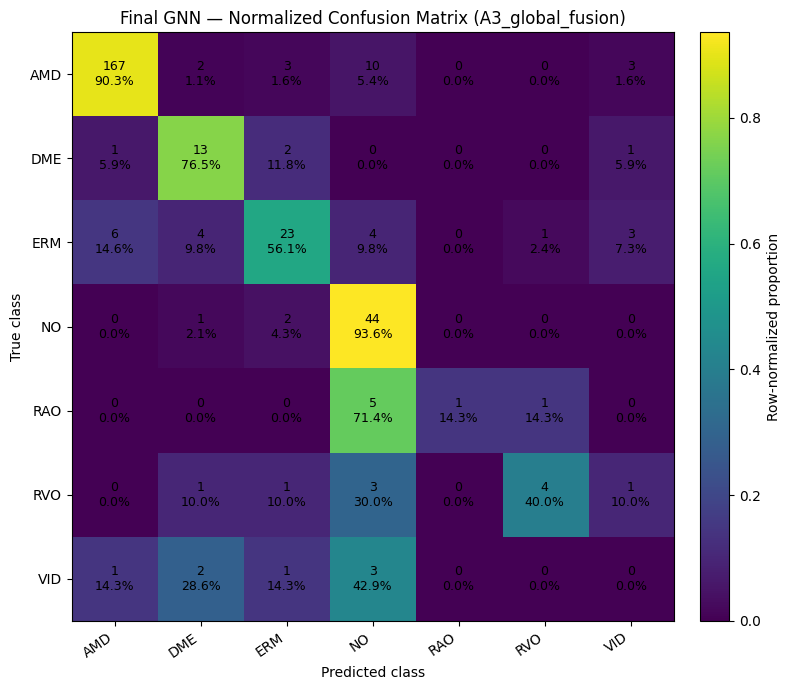

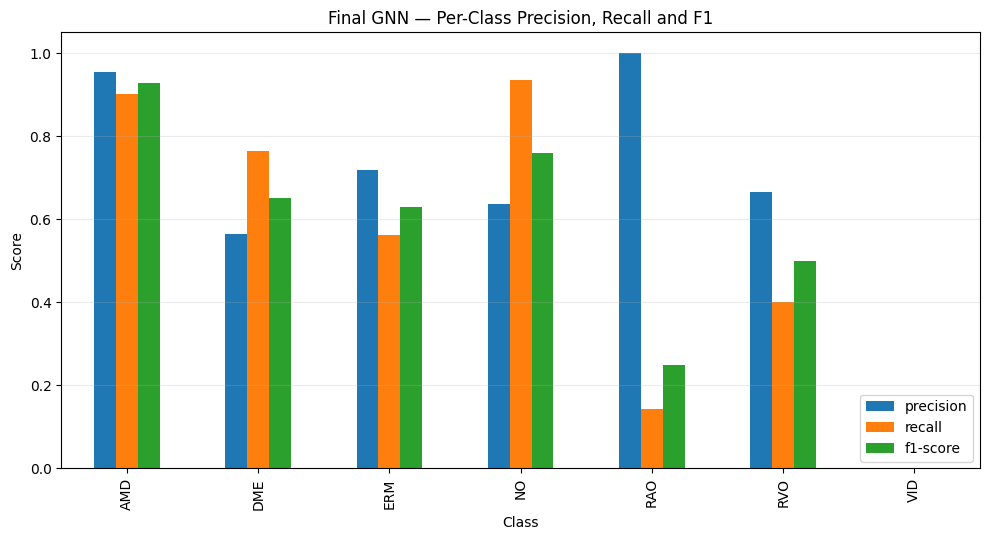

In [13]:
# 12. Confusion matrix and per-class performance for the final GNN
print(classification_report(final_test["y_true"], final_test["y_pred"],
                             target_names=classes, digits=4, zero_division=0))

cm = confusion_matrix(final_test["y_true"], final_test["y_pred"])
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_norm, aspect="auto")
ax.set_xticks(range(NUM_CLASSES), classes, rotation=35, ha="right")
ax.set_yticks(range(NUM_CLASSES), classes)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(f"Final GNN — Normalized Confusion Matrix ({best_name})")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm[i, j]}\n{cm_norm[i, j] * 100:.1f}%", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Row-normalized proportion")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "final_gnn_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

report_df = pd.DataFrame(classification_report(
    final_test["y_true"], final_test["y_pred"], target_names=classes,
    output_dict=True, zero_division=0)).T
report_df.to_csv(ARTIFACT_DIR / "final_per_class_report.csv")

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = report_df.loc[classes, ["precision", "recall", "f1-score"]]
plot_df.plot(kind="bar", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_xlabel("Class")
ax.set_title("Final GNN — Per-Class Precision, Recall and F1")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "final_per_class_metrics.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


Epoch 01 | loss 1.9520 | val acc 0.5242 | val F1 0.2021
Epoch 02 | loss 1.7504 | val acc 0.6586 | val F1 0.2079
Epoch 03 | loss 1.6341 | val acc 0.6586 | val F1 0.2065
Epoch 04 | loss 1.5215 | val acc 0.1855 | val F1 0.1520
Epoch 05 | loss 1.4540 | val acc 0.6532 | val F1 0.2222
Epoch 06 | loss 1.3900 | val acc 0.1694 | val F1 0.1691
Epoch 07 | loss 1.3360 | val acc 0.4812 | val F1 0.2936
Epoch 08 | loss 1.2600 | val acc 0.4059 | val F1 0.3344
Epoch 09 | loss 1.2062 | val acc 0.1317 | val F1 0.0613
Epoch 10 | loss 1.1694 | val acc 0.4624 | val F1 0.4176
Epoch 11 | loss 1.1388 | val acc 0.7823 | val F1 0.5803
Epoch 12 | loss 1.0875 | val acc 0.6747 | val F1 0.3567
Epoch 13 | loss 1.0770 | val acc 0.7527 | val F1 0.3825
Epoch 14 | loss 1.0420 | val acc 0.6774 | val F1 0.4839
Epoch 15 | loss 0.9681 | val acc 0.7876 | val F1 0.5431
Final GNN fold 1 {'model': 'Final GNN', 'fold': 1, 'accuracy': 0.782258064516129, 'balanced_accuracy': np.float64(0.6018389131212073), 'macro_f1': 0.58034038269

,model,fold,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Best baseline (Improved CNN),1,0.715054,0.568403,0.532779,0.735868
1,Best baseline (Improved CNN),2,0.789474,0.711267,0.568336,0.803113
2,Best baseline (Improved CNN),3,0.812139,0.716980,0.645271,0.816020
3,Best baseline (Improved CNN),4,0.758112,0.610914,0.554293,0.765343
4,Best baseline (Improved CNN),5,0.853093,0.776905,0.786729,0.851942
5,Final GNN,1,0.782258,0.601839,0.580340,0.785494
6,Final GNN,2,0.828947,0.633640,0.656276,0.818210
7,Final GNN,3,0.661850,0.570304,0.534994,0.678034
8,Final GNN,4,0.825959,0.689756,0.706521,0.825924
9,Final GNN,5,0.757732,0.624539,0.618648,0.754044


accuracy           balanced_accuracy            \
                                  mean       std              mean       std   
model                                                                          
Best baseline (Improved CNN)  0.785574  0.052457          0.676894  0.085021   
Final GNN                     0.771349  0.068180          0.624016  0.044134   

                              macro_f1           weighted_f1            
                                  mean       std        mean       std  
model                                                                   
Best baseline (Improved CNN)  0.617482  0.103682    0.794457  0.045068  
Final GNN                     0.619356  0.066334    0.772341  0.059951

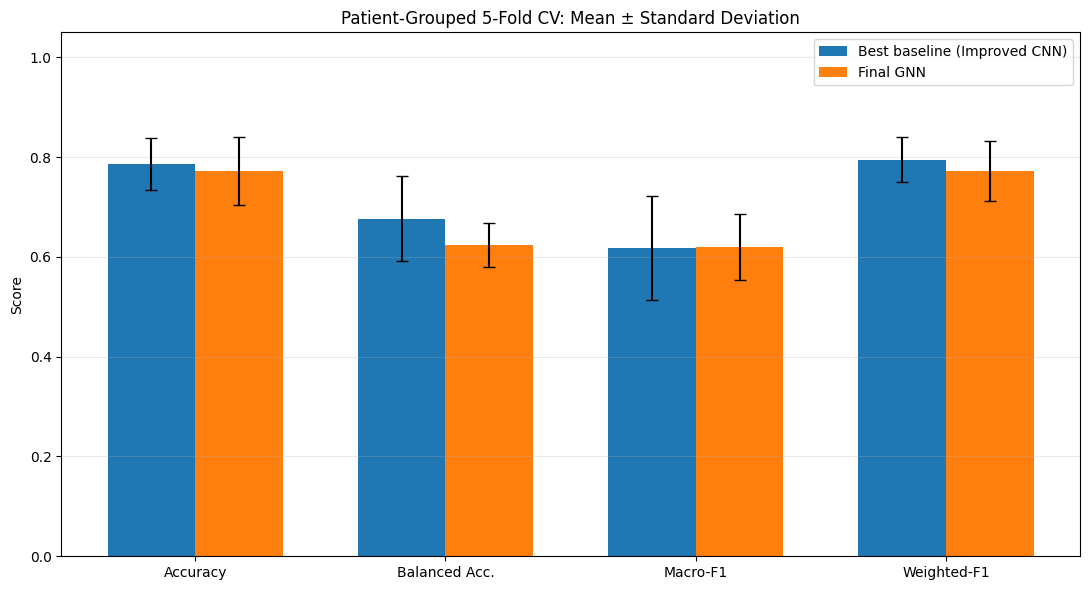

In [14]:
# 13. Leakage-free, PATIENT-GROUPED 5-fold CV on the development pool (train+val).

def make_loader(paths, labels, shuffle=True, is_train=True, transform=None):
    dataset = OCTDataset(paths, labels, transform=transform)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        drop_last=is_train,  
        num_workers=4,
        pin_memory=True
    )
dev_paths = train_paths + val_paths
dev_labels = train_labels + val_labels
dev_patients = np.concatenate([train_patients, val_patients])

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)


def cv_run_dl(model_factory, name, epochs=CV_EPOCHS):
    rows = []
    for fold, (tr, va) in enumerate(sgkf.split(dev_paths, dev_labels, groups=dev_patients), 1):
        tr_paths = [dev_paths[i] for i in tr]; tr_y = [dev_labels[i] for i in tr]
        va_paths = [dev_paths[i] for i in va]; va_y = [dev_labels[i] for i in va]
        assert not (set(dev_patients[tr]) & set(dev_patients[va])), "patient leakage in CV fold!"
        tr_loader = make_loader(tr_paths, tr_y, True, True)
        va_loader = make_loader(va_paths, va_y, False, False)
        model = model_factory()
        model, _ = train_model(model, tr_loader, va_loader, epochs=epochs,
                                optimizer_name="AdamW", class_weighted=True,
                                scheduler=True, patience=CV_PATIENCE)
        m = evaluate(model, va_loader)
        rows.append({"model": name, "fold": fold,
                      "accuracy": m["accuracy"], "balanced_accuracy": m["balanced_accuracy"],
                      "macro_f1": m["macro_f1"], "weighted_f1": m["weighted_f1"]})
        print(name, "fold", fold, rows[-1])
    return pd.DataFrame(rows)


def cv_run_classical(model_ctor, name, dev_feats):
    rows = []
    for fold, (tr, va) in enumerate(sgkf.split(dev_paths, dev_labels, groups=dev_patients), 1):
        assert not (set(dev_patients[tr]) & set(dev_patients[va])), "patient leakage in CV fold!"
        Xtr, ytr_f = dev_feats[tr], np.array(dev_labels)[tr]
        Xva, yva_f = dev_feats[va], np.array(dev_labels)[va]
        sc = StandardScaler().fit(Xtr)
        Xtr_s, Xva_s = sc.transform(Xtr), sc.transform(Xva)
        if HAS_SMOTE:
            Xtr_s, ytr_f = SMOTE(random_state=SEED).fit_resample(Xtr_s, ytr_f)
        mdl = model_ctor()
        mdl.fit(Xtr_s, ytr_f)
        pred = mdl.predict(Xva_s)
        rows.append({"model": name, "fold": fold,
                      "accuracy": accuracy_score(yva_f, pred),
                      "balanced_accuracy": balanced_accuracy_score(yva_f, pred),
                      "macro_f1": f1_score(yva_f, pred, average="macro", zero_division=0),
                      "weighted_f1": f1_score(yva_f, pred, average="weighted", zero_division=0)})
        print(name, "fold", fold, rows[-1])
    return pd.DataFrame(rows)


best_cfg = ablation_df.iloc[0]
final_factory = lambda: GNNClassifier(
    variant=str(best_cfg["cfg_variant"]), hidden=int(best_cfg["cfg_hidden"]),
    layers=int(best_cfg["cfg_layers"]), dropout=float(best_cfg["cfg_dropout"]),
    batch_norm=bool(best_cfg["cfg_batch_norm"]), graph=str(best_cfg["cfg_graph"]),
    weighted_edges=bool(best_cfg["cfg_weighted_edges"]), global_branch=bool(best_cfg["cfg_global_branch"])
)

cv_final = cv_run_dl(final_factory, "Final GNN")

if best_baseline_name == "Improved CNN":
    cnn_factory = lambda: CNNBaseline(dropout=0.30)
    cv_baseline = cv_run_dl(cnn_factory, "Best baseline (Improved CNN)")
else:
    dev_feats = np.concatenate([Xtr_feat, Xval_feat], axis=0)  # reuse features extracted earlier
    ctor_map = {
        "LogisticRegression": lambda: LogisticRegression(max_iter=2000, random_state=SEED, n_jobs=-1),
        "RandomForest": lambda: RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
        "GradientBoosting": lambda: GradientBoostingClassifier(random_state=SEED),
        "SVM_RBF": lambda: SVC(kernel="rbf", probability=True, random_state=SEED),
    }
    cv_baseline = cv_run_classical(ctor_map[best_baseline_name],
                                    f"Best baseline ({best_baseline_name})", dev_feats)

cv_results = pd.concat([cv_baseline, cv_final], ignore_index=True)
display(cv_results)
cv_results.to_csv(ARTIFACT_DIR / "five_fold_cv.csv", index=False)

cv_summary = cv_results.groupby("model")[["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]] \
    .agg(["mean", "std"])
display(cv_summary)
cv_summary.to_csv(ARTIFACT_DIR / "five_fold_cv_summary.csv")

metric_order = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]
means = cv_results.groupby("model")[metric_order].mean()
stds = cv_results.groupby("model")[metric_order].std().fillna(0)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(metric_order))
width = 0.35
for j, model_name in enumerate(means.index):
    ax.bar(x + (j - 0.5) * width, means.loc[model_name].values, width,
           yerr=stds.loc[model_name].values, capsize=4, label=model_name)
ax.set_xticks(x, ["Accuracy", "Balanced Acc.", "Macro-F1", "Weighted-F1"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Patient-Grouped 5-Fold CV: Mean ± Standard Deviation")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "five_fold_cv_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


In [15]:
# 14. PRIMARY significance test: Wilcoxon signed-rank across the 5 paired CV folds.

cv_pivot = cv_results.pivot(index="fold", columns="model", values="macro_f1")
baseline_col = [c for c in cv_pivot.columns if c != "Final GNN"][0]
final_scores = cv_pivot["Final GNN"].values
baseline_scores = cv_pivot[baseline_col].values

print("Paired macro-F1 per fold:")
display(cv_pivot)

if np.allclose(final_scores, baseline_scores):
    wilcoxon_stat, wilcoxon_p = np.nan, 1.0
else:
    wilcoxon_stat, wilcoxon_p = wilcoxon(final_scores, baseline_scores)

print(f"\nWilcoxon signed-rank test (Final GNN vs {baseline_col}, 5 paired fold macro-F1 scores)")
print(f"statistic = {wilcoxon_stat}")
print(f"p-value   = {wilcoxon_p:.4f}")
print(f"Significant at alpha={ALPHA}:", wilcoxon_p < ALPHA)
print("Mean macro-F1 — Final GNN:", round(final_scores.mean(), 4),
      "| Best baseline:", round(baseline_scores.mean(), 4))

pd.DataFrame([{
    "test": "Wilcoxon signed-rank (paired, 5-fold CV, macro_f1)",
    "compared": f"Final GNN vs {baseline_col}",
    "statistic": wilcoxon_stat,
    "p_value": wilcoxon_p,
    "alpha": ALPHA,
    "significant": bool(wilcoxon_p < ALPHA),
    "final_gnn_mean": final_scores.mean(),
    "baseline_mean": baseline_scores.mean(),
}]).to_csv(ARTIFACT_DIR / "significance_test_PRIMARY_wilcoxon.csv", index=False)

if final_scores.mean() < baseline_scores.mean():
    print("\n*** NOTE: under patient-grouped 5-fold CV, the baseline currently scores "
          "HIGHER on average than the Final GNN. Do not silently report the single-split "
          "'improvement' as the headline result if this holds — investigate (e.g. GNN "
          "capacity/regularization, CV_EPOCHS, learning-rate schedule) and report the CV "
          "outcome honestly in the report, since it is the more reliable of the two. ***")


Paired macro-F1 per fold:


model,Best baseline (Improved CNN),Final GNN
fold,,
1,0.532779,0.580340
2,0.568336,0.656276
3,0.645271,0.534994
4,0.554293,0.706521
5,0.786729,0.618648



Wilcoxon signed-rank test (Final GNN vs Best baseline (Improved CNN), 5 paired fold macro-F1 scores)
statistic = 7.0
p-value   = 1.0000
Significant at alpha=0.05: False
Mean macro-F1 — Final GNN: 0.6194 | Best baseline: 0.6175


In [16]:
# 15. SECONDARY / supplementary test

baseline_correct = (np.asarray(best_baseline_pred_test) == yte)
gnn_correct = (final_test["y_pred"] == final_test["y_true"])

b_only = int(np.sum(baseline_correct & ~gnn_correct))
g_only = int(np.sum(gnn_correct & ~baseline_correct))
discordant = b_only + g_only

if HAS_STATSMODELS:
    table = [[0, b_only], [g_only, 0]]
    mcnemar_result = sm_mcnemar(table, exact=True)
    mcnemar_stat, mcnemar_p = mcnemar_result.statistic, mcnemar_result.pvalue
    test_name = "Exact McNemar (statsmodels)"
else:
    mcnemar_stat = g_only
    mcnemar_p = 1.0 if discordant == 0 else binomtest(g_only, discordant, 0.5, alternative="two-sided").pvalue
    test_name = "Exact binomial sign test (McNemar-equivalent, statsmodels unavailable)"

print(f"Best-baseline-only correct: {b_only}")
print(f"Final-GNN-only correct: {g_only}")
print(f"{test_name} statistic: {mcnemar_stat}")
print(f"{test_name} p-value: {mcnemar_p}")
print(f"Significant at alpha={ALPHA}:", mcnemar_p < ALPHA)

pd.DataFrame([{
    "test": test_name,
    "compared": f"Final GNN vs Best baseline ({best_baseline_name}), single held-out test set",
    "baseline_only_correct": b_only,
    "gnn_only_correct": g_only,
    "discordant_pairs": discordant,
    "statistic": mcnemar_stat,
    "p_value": mcnemar_p,
    "alpha": ALPHA,
    "significant": bool(mcnemar_p < ALPHA),
    "role": "secondary/supplementary — see section 14 for the primary CV-based test",
}]).to_csv(ARTIFACT_DIR / "significance_test_SECONDARY_mcnemar.csv", index=False)


Best-baseline-only correct: 12
Final-GNN-only correct: 17
Exact McNemar (statsmodels) statistic: 12.0
Exact McNemar (statsmodels) p-value: 0.45825831964612007
Significant at alpha=0.05: False


In [17]:
# 16. Machine-readable experiment manifest.
manifest = {
    "dataset": "OCTDL",
    "classes": classes,
    "image_size": IMAGE_SIZE,
    "grid_size": GRID_SIZE,
    "split": "70/15/15, PATIENT-GROUPED (GroupShuffleSplit on patient_id), random_state=42",
    "cv_scheme": "5-fold StratifiedGroupKFold on patient_id (dev pool = train+val), "
                 f"epochs={CV_EPOCHS} (matches main training run)",
    "augmentation": "horizontal flip + small affine transform on training only",
    "graph_node_definition": "8x8 spatial image patches",
    "primary_metric": "validation macro-F1 (model selection)",
    "secondary_metrics": ["accuracy", "balanced_accuracy", "weighted_f1"],
    "best_baseline": best_baseline_name,
    "final_model": best_name,
    "significance_tests": {
        "primary": "Wilcoxon signed-rank across 5 paired CV-fold macro-F1 scores "
                   "(Final GNN vs best baseline) — see significance_test_PRIMARY_wilcoxon.csv",
        "secondary": "Exact McNemar on the single held-out test set — see "
                     "significance_test_SECONDARY_mcnemar.csv",
    },
    "related_work_file": str(ARTIFACT_DIR / "related_work.csv"),
    "ablation_file": str(ARTIFACT_DIR / "ablation_results.csv"),
    "cv_file": str(ARTIFACT_DIR / "five_fold_cv.csv"),
    "model_improvements": [
        "stronger patch CNN encoder", "residual GCN layers", "attention pooling",
        "optional global image branch", "AdamW + ReduceLROnPlateau",
        "class-weighted label-smoothed loss", "gradient clipping", "early stopping",
        "GraphSAGE variant added to the ablation sweep (A6)",
        "optimizer and LR-schedule isolated as separate ablation axes (A7, A8)",
    ]
}
save_json(manifest, ARTIFACT_DIR / "task3_manifest.json")
save_json(manifest, MODELS_DIR / "task3_manifest.json")
print(json.dumps(manifest, indent=2))


{
  "dataset": "OCTDL",
  "classes": [
    "AMD",
    "DME",
    "ERM",
    "NO",
    "RAO",
    "RVO",
    "VID"
  ],
  "image_size": 128,
  "grid_size": 8,
  "split": "70/15/15, PATIENT-GROUPED (GroupShuffleSplit on patient_id), random_state=42",
  "cv_scheme": "5-fold StratifiedGroupKFold on patient_id (dev pool = train+val), epochs=25 (matches main training run)",
  "augmentation": "horizontal flip + small affine transform on training only",
  "graph_node_definition": "8x8 spatial image patches",
  "primary_metric": "validation macro-F1 (model selection)",
  "secondary_metrics": [
    "accuracy",
    "balanced_accuracy",
    "weighted_f1"
  ],
  "best_baseline": "Improved CNN",
  "final_model": "A3_global_fusion",
  "significance_tests": {
    "primary": "Wilcoxon signed-rank across 5 paired CV-fold macro-F1 scores (Final GNN vs best baseline) \u2014 see significance_test_PRIMARY_wilcoxon.csv",
    "secondary": "Exact McNemar on the single held-out test set \u2014 see significance_